In [1]:
!pip install pyspark faker -q

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TransactionStreamingPipeline") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"PySpark version : {spark.version}")
print("Spark OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.1 MB/s eta 0:00:00
PySpark version : 4.0.2
Spark OK


In [9]:
import os, json, random
from faker import Faker
from datetime import datetime, timedelta

fake = Faker()
os.makedirs("/content/input/transactions", exist_ok=True)
os.makedirs("/content/output/streaming", exist_ok=True)
os.makedirs("/content/output/checkpoint", exist_ok=True)
os.makedirs("/content/output/quality", exist_ok=True)

CATEGORIES = ["food", "transport", "shopping", "healthcare",
               "entertainment", "utilities", "travel", "education"]

RISK_PROFILES = {
    "low":    {"amount_range": (10, 500),    "fraud_prob": 0.01},
    "medium": {"amount_range": (500, 2000),  "fraud_prob": 0.05},
    "high":   {"amount_range": (2000, 10000),"fraud_prob": 0.15},
}

# Poids horaires réalistes : pic matin, midi, soir
HOUR_WEIGHTS = [1,1,1,1,1,2,3,5,8,8,6,5,8,8,6,5,7,7,9,8,6,4,3,2]

def generate_transaction():
    profile_name = random.choices(
        ["low", "medium", "high"], weights=[0.6, 0.3, 0.1]
    )[0]
    profile = RISK_PROFILES[profile_name]
    amount  = round(random.uniform(*profile["amount_range"]), 2)

    # Heure réaliste
    hour   = random.choices(range(24), weights=HOUR_WEIGHTS)[0]
    minute = random.randint(0, 59)
    second = random.randint(0, 59)

    # Fraude plus probable la nuit (0h-6h)
    night_multiplier = 2.5 if hour < 6 else 1.0
    fraud_prob = profile["fraud_prob"] * night_multiplier
    is_fraud   = random.random() < fraud_prob

    # Date aléatoire sur les 30 derniers jours
    base_date = datetime.now() - timedelta(days=random.randint(0, 30))
    timestamp = base_date.replace(hour=hour, minute=minute, second=second)

    return {
        "transaction_id": fake.uuid4(),
        "client_id":      f"CLIENT_{random.randint(1, 200):04d}",
        "amount":         amount,
        "category":       random.choice(CATEGORIES),
        "merchant":       fake.company(),
        "location":       fake.city(),
        "risk_profile":   profile_name,
        "is_fraud":       int(is_fraud),
        "timestamp":      timestamp.strftime("%Y-%m-%d %H:%M:%S"),
    }

def generate_batch(n=50, batch_id=0):
    # Supprimer les anciens fichiers
    import glob
    for f in glob.glob("/content/input/transactions/*.json"):
        os.remove(f)

    transactions = [generate_transaction() for _ in range(n)]
    path = f"/content/input/transactions/batch_{batch_id:04d}.json"
    with open(path, "w") as f:
        for t in transactions:
            f.write(json.dumps(t) + "\n")
    return len(transactions)

# Générer 10 batches = 500 transactions
for i in range(10):
    # Ne pas supprimer à chaque batch
    transactions = [generate_transaction() for _ in range(50)]
    path = f"/content/input/transactions/batch_{i:04d}.json"
    with open(path, "w") as f:
        for t in transactions:
            f.write(json.dumps(t) + "\n")
    print(f"Batch {i} généré — 50 transactions")

print(f"\nTotal fichiers : {len(os.listdir('/content/input/transactions'))}")
print("Exemple de transaction :")
print(json.dumps(generate_transaction(), indent=2))

Batch 0 généré — 50 transactions
Batch 1 généré — 50 transactions
Batch 2 généré — 50 transactions
Batch 3 généré — 50 transactions
Batch 4 généré — 50 transactions
Batch 5 généré — 50 transactions
Batch 6 généré — 50 transactions
Batch 7 généré — 50 transactions
Batch 8 généré — 50 transactions
Batch 9 généré — 50 transactions

Total fichiers : 10
Exemple de transaction :
{
  "transaction_id": "0b9eff98-c180-47d2-9924-2a7594c61799",
  "client_id": "CLIENT_0185",
  "amount": 209.04,
  "category": "education",
  "merchant": "Guzman LLC",
  "location": "South Henrytown",
  "risk_profile": "low",
  "is_fraud": 0,
  "timestamp": "2026-04-22 18:04:12"
}


In [10]:
from pyspark.sql.types import *
from pyspark.sql import functions as F

# Schema strict des transactions
schema = StructType([
    StructField("transaction_id", StringType(),  nullable=False),
    StructField("client_id",      StringType(),  nullable=False),
    StructField("amount",         DoubleType(),  nullable=False),
    StructField("category",       StringType(),  nullable=True),
    StructField("merchant",       StringType(),  nullable=True),
    StructField("location",       StringType(),  nullable=True),
    StructField("risk_profile",   StringType(),  nullable=True),
    StructField("is_fraud",       IntegerType(), nullable=False),
    StructField("timestamp",      StringType(),  nullable=False),
])

# Lecture batch (simule un flux Kafka)
df_raw = spark.read \
    .schema(schema) \
    .json("/content/input/transactions/")

# Cast timestamp
df = df_raw.withColumn(
    "timestamp",
    F.to_timestamp(F.col("timestamp"), "yyyy-MM-dd HH:mm:ss")
)

print(f"Transactions chargées : {df.count()}")
print(f"Schema :")
df.printSchema()
print("\nAperçu :")
df.show(5, truncate=False)

Transactions chargées : 500
Schema :
root
 |-- transaction_id: string (nullable = true)
 |-- client_id: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- category: string (nullable = true)
 |-- merchant: string (nullable = true)
 |-- location: string (nullable = true)
 |-- risk_profile: string (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)


Aperçu :
+------------------------------------+-----------+-------+-------------+--------------------------+----------------+------------+--------+-------------------+
|transaction_id                      |client_id  |amount |category     |merchant                  |location        |risk_profile|is_fraud|timestamp          |
+------------------------------------+-----------+-------+-------------+--------------------------+----------------+------------+--------+-------------------+
|e71b8e35-6cc3-42d9-9c51-95e1ce4f452b|CLIENT_0010|444.25 |healthcare   |Lara-Stewart            

In [11]:

df_clean = df \
    .filter(F.col("amount") > 0) \
    .filter(F.col("client_id").isNotNull()) \
    .filter(F.col("transaction_id").isNotNull()) \
    .dropDuplicates(["transaction_id"])

print(f"Après nettoyage : {df_clean.count()} transactions")

# ── FEATURE ENGINEERING
from pyspark.sql.window import Window

# Window par client (comportement historique)
w_client = Window.partitionBy("client_id").orderBy("timestamp")
w_client_all = Window.partitionBy("client_id")

df_features = df_clean \
    .withColumn("hour_of_day",
                F.hour(F.col("timestamp"))) \
    .withColumn("day_of_week",
                F.dayofweek(F.col("timestamp"))) \
    .withColumn("is_night",
                F.when(F.col("hour_of_day").between(0, 6), 1).otherwise(0)) \
    .withColumn("is_weekend",
                F.when(F.col("day_of_week").isin([1, 7]), 1).otherwise(0)) \
    .withColumn("cumulative_amount",
                F.sum("amount").over(w_client)) \
    .withColumn("n_transactions_client",
                F.count("transaction_id").over(w_client_all)) \
    .withColumn("avg_amount_client",
                F.avg("amount").over(w_client_all)) \
    .withColumn("amount_vs_avg",
                F.col("amount") / (F.col("avg_amount_client") + 1e-6)) \
    .withColumn("risk_score",
                F.when(F.col("risk_profile") == "high",   3)
                 .when(F.col("risk_profile") == "medium", 2)
                 .otherwise(1)) \
    .withColumn("high_risk_flag",
                F.when(
                    (F.col("risk_profile") == "high") &
                    (F.col("amount_vs_avg") > 2.0), 1
                ).otherwise(0))

print("Features créées :")
df_features.select(
    "client_id", "amount", "avg_amount_client",
    "amount_vs_avg", "risk_score", "high_risk_flag",
    "is_night", "cumulative_amount"
).show(10, truncate=False)

Après nettoyage : 500 transactions
Features créées :
+-----------+-------+-----------------+-------------------+----------+--------------+--------+-----------------+
|client_id  |amount |avg_amount_client|amount_vs_avg      |risk_score|high_risk_flag|is_night|cumulative_amount|
+-----------+-------+-----------------+-------------------+----------+--------------+--------+-----------------+
|CLIENT_0001|414.54 |1017.71          |0.40732625167550063|1         |0             |0       |414.54           |
|CLIENT_0001|1620.88|1017.71          |1.592673746359303  |2         |0             |0       |2035.42          |
|CLIENT_0002|195.83 |924.27           |0.21187531758915112|1         |0             |0       |195.83           |
|CLIENT_0002|1652.71|924.27           |1.788124680246979  |2         |0             |0       |1848.54          |
|CLIENT_0003|333.95 |894.27           |0.37343307907742285|1         |0             |1       |333.95           |
|CLIENT_0003|1454.59|894.27           |1.62

In [12]:
# ── AGREGATIONS PAR CLIENT ───────────────────────────────────────────────────
client_stats = df_features \
    .groupBy("client_id") \
    .agg(
        F.count("transaction_id").alias("total_transactions"),
        F.sum("amount").alias("total_amount"),
        F.avg("amount").alias("avg_amount"),
        F.max("amount").alias("max_amount"),
        F.min("amount").alias("min_amount"),
        F.stddev("amount").alias("std_amount"),
        F.sum("is_fraud").alias("n_fraud"),
        F.sum("high_risk_flag").alias("n_high_risk"),
        F.sum("is_night").alias("n_night_transactions"),
        F.sum("is_weekend").alias("n_weekend_transactions"),
        F.countDistinct("category").alias("n_categories"),
        F.countDistinct("location").alias("n_locations"),
    ) \
    .withColumn("fraud_rate",
                F.col("n_fraud") / F.col("total_transactions")) \
    .withColumn("high_risk_rate",
                F.col("n_high_risk") / F.col("total_transactions")) \
    .withColumn("night_rate",
                F.col("n_night_transactions") / F.col("total_transactions")) \
    .withColumn("client_risk_label",
                F.when(F.col("fraud_rate") > 0.10, "HIGH")
                 .when(F.col("fraud_rate") > 0.03, "MEDIUM")
                 .otherwise("LOW")) \
    .orderBy(F.col("fraud_rate").desc())

print("=== Profils clients par risque ===")
client_stats.show(10, truncate=False)

# ── AGREGATIONS PAR CATEGORIE ────────────────────────────────────────────────
category_stats = df_features \
    .groupBy("category") \
    .agg(
        F.count("*").alias("total_transactions"),
        F.sum("amount").alias("total_amount"),
        F.avg("amount").alias("avg_amount"),
        F.sum("is_fraud").alias("n_fraud"),
        (F.sum("is_fraud") / F.count("*")).alias("fraud_rate"),
    ) \
    .orderBy(F.col("fraud_rate").desc())

print("=== Fraude par catégorie ===")
category_stats.show(truncate=False)

# ── AGREGATIONS PAR HEURE ────────────────────────────────────────────────────
hourly_stats = df_features \
    .groupBy("hour_of_day") \
    .agg(
        F.count("*").alias("n_transactions"),
        F.avg("amount").alias("avg_amount"),
        F.sum("is_fraud").alias("n_fraud"),
        (F.sum("is_fraud") / F.count("*")).alias("fraud_rate"),
    ) \
    .orderBy("hour_of_day")

print("=== Distribution horaire ===")
hourly_stats.show(24, truncate=False)

=== Profils clients par risque ===
+-----------+------------------+-----------------+------------------+----------+----------+------------------+-------+-----------+--------------------+----------------------+------------+-----------+------------------+------------------+------------------+-----------------+
|client_id  |total_transactions|total_amount     |avg_amount        |max_amount|min_amount|std_amount        |n_fraud|n_high_risk|n_night_transactions|n_weekend_transactions|n_categories|n_locations|fraud_rate        |high_risk_rate    |night_rate        |client_risk_label|
+-----------+------------------+-----------------+------------------+----------+----------+------------------+-------+-----------+--------------------+----------------------+------------+-----------+------------------+------------------+------------------+-----------------+
|CLIENT_0175|1                 |1382.37          |1382.37           |1382.37   |1382.37   |NULL              |1      |0          |0         

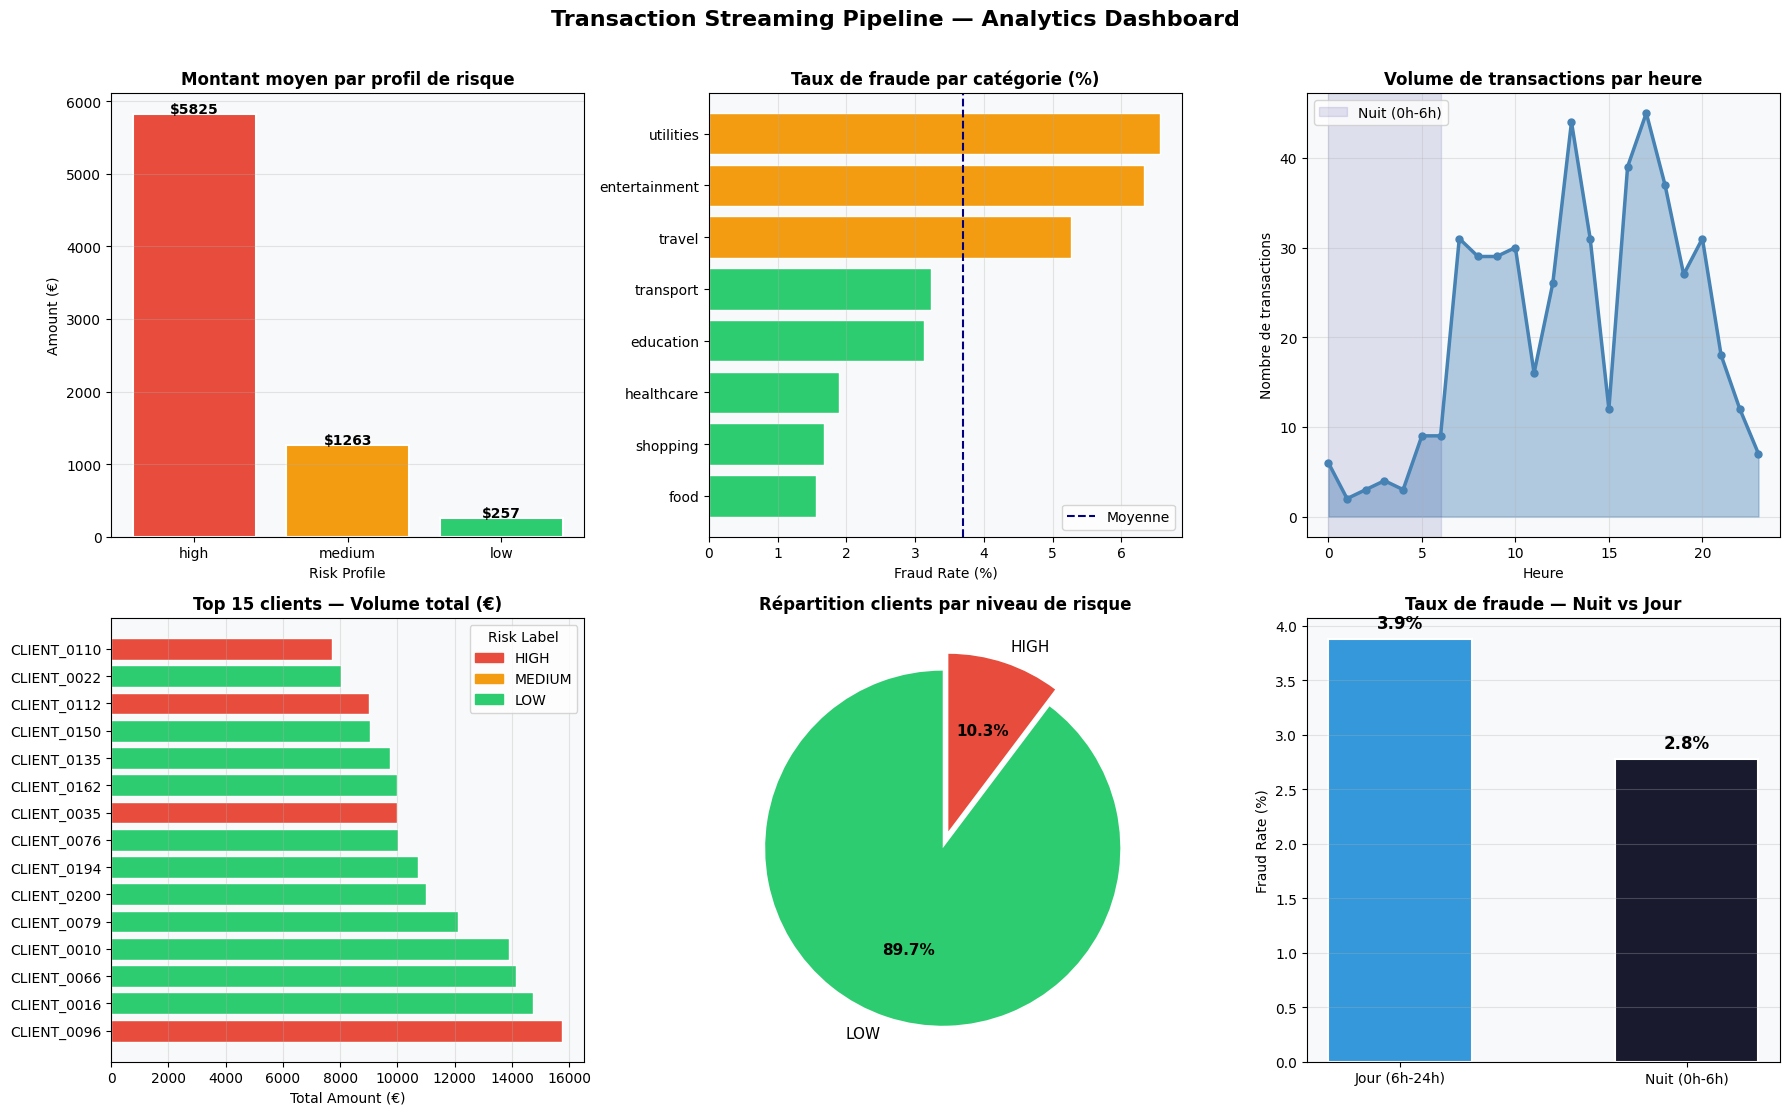

Dashboard sauvegardé.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Convertir en pandas pour visualisation
client_pd   = client_stats.toPandas()
category_pd = category_stats.toPandas()
hourly_pd   = hourly_stats.toPandas()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Transaction Streaming Pipeline — Analytics Dashboard",
             fontsize=16, fontweight="bold", y=1.01)

# ── Fig 1 : Distribution des montants par profil de risque ──────────────────
ax1 = axes[0, 0]
risk_amount = df_features.groupBy("risk_profile") \
    .agg(F.avg("amount").alias("avg"), F.count("*").alias("n")) \
    .toPandas()
colors = {"low": "#2ECC71", "medium": "#F39C12", "high": "#E74C3C"}
bars = ax1.bar(risk_amount["risk_profile"],
               risk_amount["avg"],
               color=[colors[r] for r in risk_amount["risk_profile"]],
               edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, risk_amount["avg"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"${val:.0f}", ha="center", fontsize=10, fontweight="bold")
ax1.set_title("Montant moyen par profil de risque", fontweight="bold")
ax1.set_xlabel("Risk Profile")
ax1.set_ylabel("Amount (€)")
ax1.set_facecolor("#F8F9FA")
ax1.grid(axis="y", alpha=0.3)

# ── Fig 2 : Taux de fraude par catégorie ────────────────────────────────────
ax2 = axes[0, 1]
cat_sorted = category_pd.sort_values("fraud_rate", ascending=True)
colors_cat = ["#E74C3C" if r > 0.08 else "#F39C12" if r > 0.04
              else "#2ECC71" for r in cat_sorted["fraud_rate"]]
ax2.barh(cat_sorted["category"], cat_sorted["fraud_rate"] * 100,
         color=colors_cat, edgecolor="white")
ax2.axvline(x=cat_sorted["fraud_rate"].mean() * 100,
            color="navy", ls="--", lw=1.5, label="Moyenne")
ax2.set_title("Taux de fraude par catégorie (%)", fontweight="bold")
ax2.set_xlabel("Fraud Rate (%)")
ax2.legend()
ax2.set_facecolor("#F8F9FA")
ax2.grid(axis="x", alpha=0.3)

# ── Fig 3 : Distribution horaire des transactions ────────────────────────────
ax3 = axes[0, 2]
ax3.fill_between(hourly_pd["hour_of_day"],
                 hourly_pd["n_transactions"],
                 alpha=0.4, color="steelblue")
ax3.plot(hourly_pd["hour_of_day"],
         hourly_pd["n_transactions"],
         color="steelblue", lw=2.5, marker="o", ms=5)
ax3.axvspan(0, 6, alpha=0.1, color="navy", label="Nuit (0h-6h)")
ax3.set_title("Volume de transactions par heure", fontweight="bold")
ax3.set_xlabel("Heure")
ax3.set_ylabel("Nombre de transactions")
ax3.legend()
ax3.set_facecolor("#F8F9FA")
ax3.grid(alpha=0.3)

# ── Fig 4 : Top 15 clients par montant total ─────────────────────────────────
ax4 = axes[1, 0]
top_clients = client_pd.nlargest(15, "total_amount")
risk_colors = {"HIGH": "#E74C3C", "MEDIUM": "#F39C12", "LOW": "#2ECC71"}
bar_colors  = [risk_colors[r] for r in top_clients["client_risk_label"]]
ax4.barh(top_clients["client_id"], top_clients["total_amount"],
         color=bar_colors, edgecolor="white")
ax4.set_title("Top 15 clients — Volume total (€)", fontweight="bold")
ax4.set_xlabel("Total Amount (€)")
ax4.set_facecolor("#F8F9FA")
ax4.grid(axis="x", alpha=0.3)
patches = [mpatches.Patch(color=v, label=k) for k, v in risk_colors.items()]
ax4.legend(handles=patches, title="Risk Label")

# ── Fig 5 : Répartition des labels de risque client ─────────────────────────
ax5 = axes[1, 1]
risk_counts = client_pd["client_risk_label"].value_counts()
explode = [0.05] * len(risk_counts)
wedge_colors = [risk_colors.get(r, "gray") for r in risk_counts.index]
wedges, texts, autotexts = ax5.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors,
    explode=explode,
    startangle=90,
    textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontweight("bold")
ax5.set_title("Répartition clients par niveau de risque", fontweight="bold")

# ── Fig 6 : Fraude — nuit vs jour ────────────────────────────────────────────
ax6 = axes[1, 2]
night_fraud = df_features.groupBy("is_night") \
    .agg(
        F.sum("is_fraud").alias("n_fraud"),
        F.count("*").alias("total"),
        (F.sum("is_fraud") / F.count("*")).alias("fraud_rate")
    ).toPandas()

labels  = ["Jour (6h-24h)", "Nuit (0h-6h)"]
rates   = night_fraud.sort_values("is_night")["fraud_rate"].values * 100
colors2 = ["#3498DB", "#1A1A2E"]
bars2   = ax6.bar(labels, rates, color=colors2,
                  edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars2, rates):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold",
             color="black")
ax6.set_title("Taux de fraude — Nuit vs Jour", fontweight="bold")
ax6.set_ylabel("Fraud Rate (%)")
ax6.set_facecolor("#F8F9FA")
ax6.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/dashboard_streaming.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard sauvegardé.")